# Importar datos

[Daily Climate time series data](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)

In [1]:
import kagglehub

path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\efrai\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3


In [2]:
from pathlib import Path

files_list = list(Path(path).glob('**/*'))
files_list

[WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTest.csv'),
 WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTrain.csv')]

In [3]:
file_dict = {file.stem: file for file in files_list if file.is_file()}
display(file_dict)

{'DailyDelhiClimateTest': WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTest.csv'),
 'DailyDelhiClimateTrain': WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTrain.csv')}

In [4]:
import pandas as pd

df = pd.read_csv(file_dict['DailyDelhiClimateTrain'])

print(df.shape)
df.head()

(1462, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


# Entrenar
Una red neuronal que pueda predecir la temperatura del siguiente día en los siguientes rangos:
- `< 14`
- `14 a 22`
- `22 a 27`
- `27 a 33`
- `> 33`

In [5]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by='date', ascending=True, inplace=True)
df.set_index('date', inplace=True)

df.sample(5)

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-11-07,24.545455,51.318182,8.172727,1012.772727
2014-06-14,30.500000,66.875000,6.487500,997.375000
2013-04-24,30.285714,41.714286,2.114286,1008.571429
2016-09-16,31.400000,58.000000,3.520000,1004.400000
2014-10-30,23.875000,61.375000,1.850000,1014.500000


In [6]:
df.index.diff().value_counts(dropna=False)

date
1 days    1461
NaT          1
Name: count, dtype: int64

In [7]:
df['year'] = df.index.year
display(df['year'].value_counts(normalize=False, dropna=False, sort=False))

df.head()

year
2013    365
2014    365
2015    365
2016    366
2017      1
Name: count, dtype: int64

,meantemp,humidity,wind_speed,meanpressure,year
date,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013
2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013
2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013
2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013
2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013


In [8]:
df = df[df['year'] != 2017].copy()
display(df['year'].value_counts(normalize=False, dropna=False, sort=False))

year
2013    365
2014    365
2015    365
2016    366
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for plotting multiple features
df_melted = df.melt(id_vars=['year'], var_name='feature', value_name='value')

df_melted.sample(5)

,year,feature,value
200,2013,meantemp,26.833333
4707,2013,meanpressure,1013.125000
4594,2013,meanpressure,996.666667
1632,2013,humidity,47.333333
2245,2015,humidity,72.375000


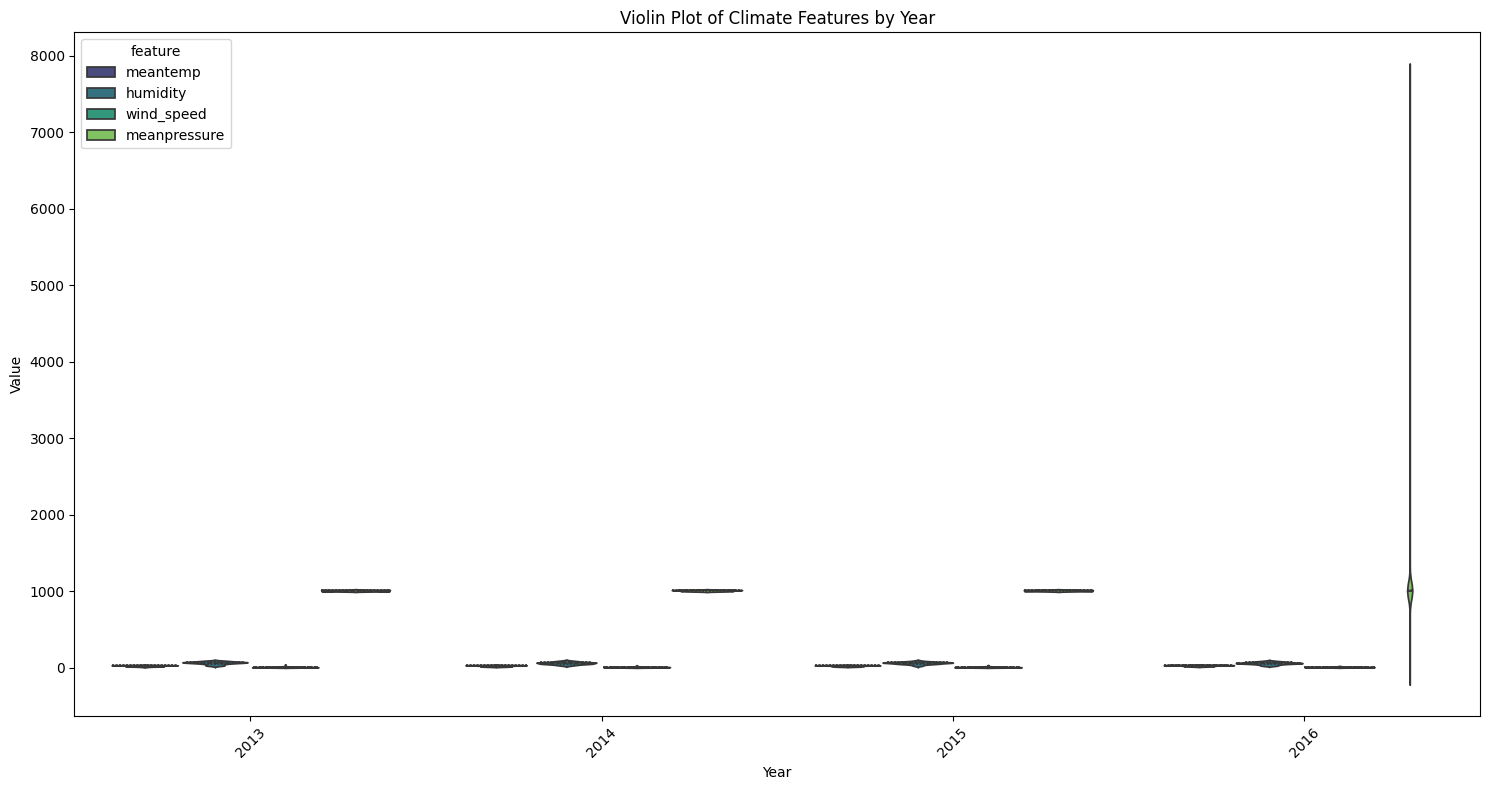

In [10]:
# Create the violin plot
plt.figure(figsize=(15, 8))
sns.violinplot(data=df_melted, x='year', y='value', hue='feature', inner='quartile', palette='viridis')
plt.title('Violin Plot of Climate Features by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Anomaly Detection using Isolation Forest

I will now use the Isolation Forest algorithm to detect anomalies in the dataset. Isolation Forest is an unsupervised learning algorithm that works by isolating observations instead of profiling normal observations. It is particularly effective for high-dimensional datasets.

In [11]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
# contamination is the proportion of outliers in the data set.
# A value between 0 and 0.5 can be specified. Here, I'm setting it to 'auto'
# random_state is for reproducibility
model = IsolationForest(contamination='auto', random_state=42)

# Fit the model and predict anomalies
# The predict method returns -1 for outliers and 1 for inliers.
df['anomaly_score'] = model.fit_predict(df) == -1

df['anomaly_score'].value_counts(normalize=True, dropna=False)

anomaly_score
False    0.787817
True     0.212183
Name: proportion, dtype: float64

Now, let's visualize the anomalies.

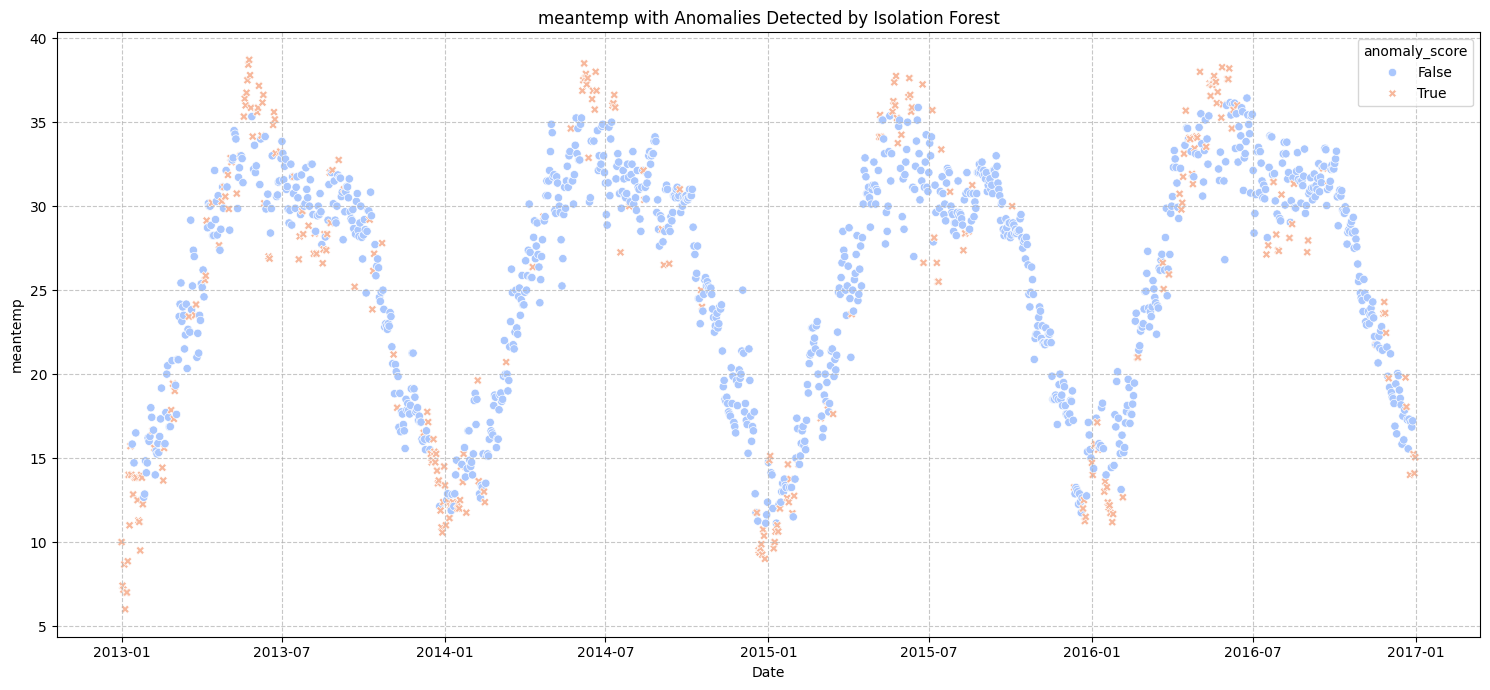

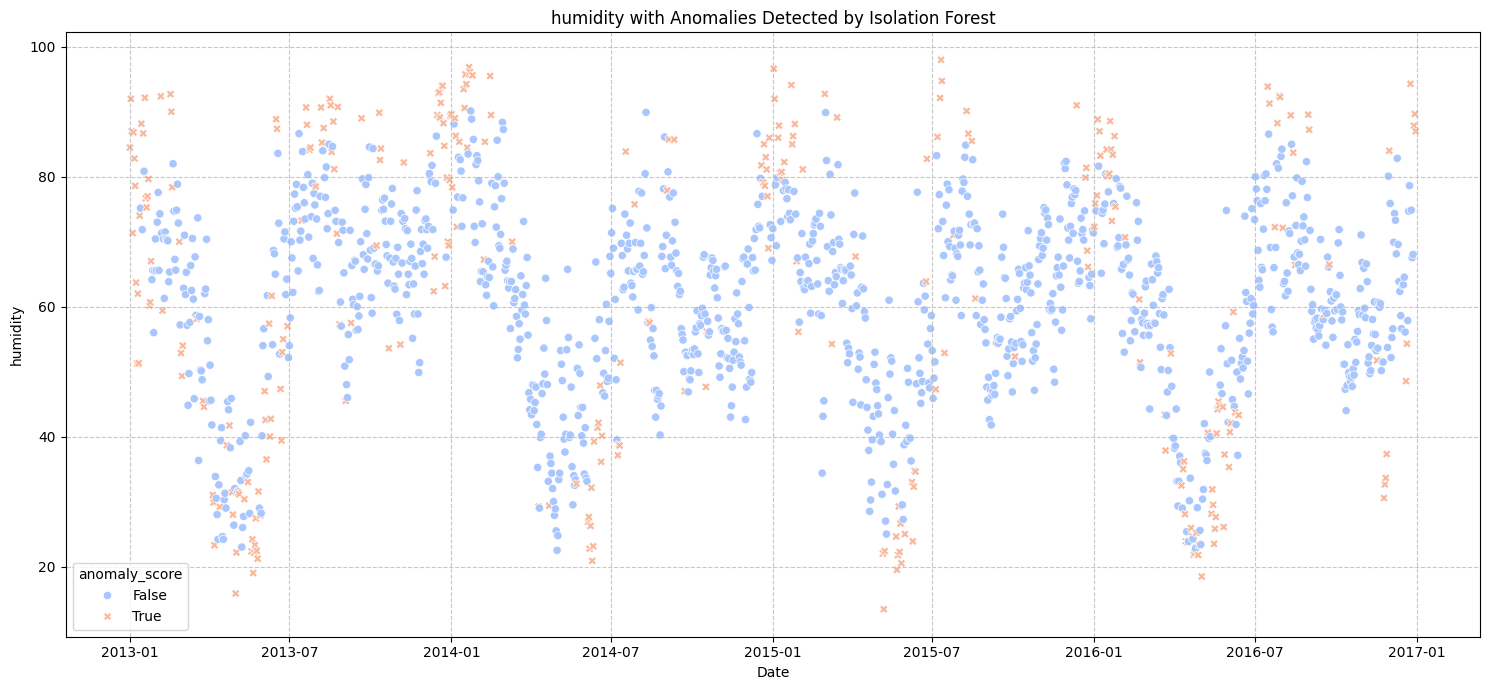

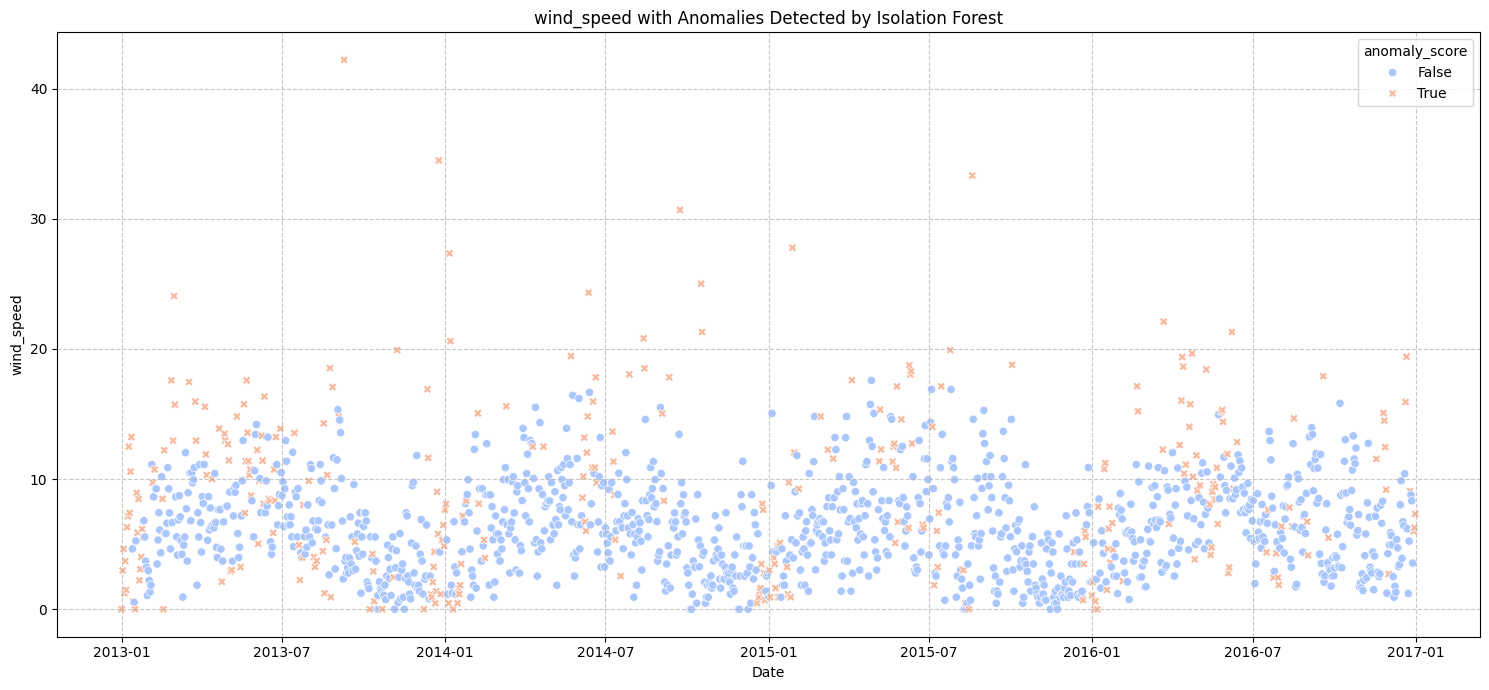

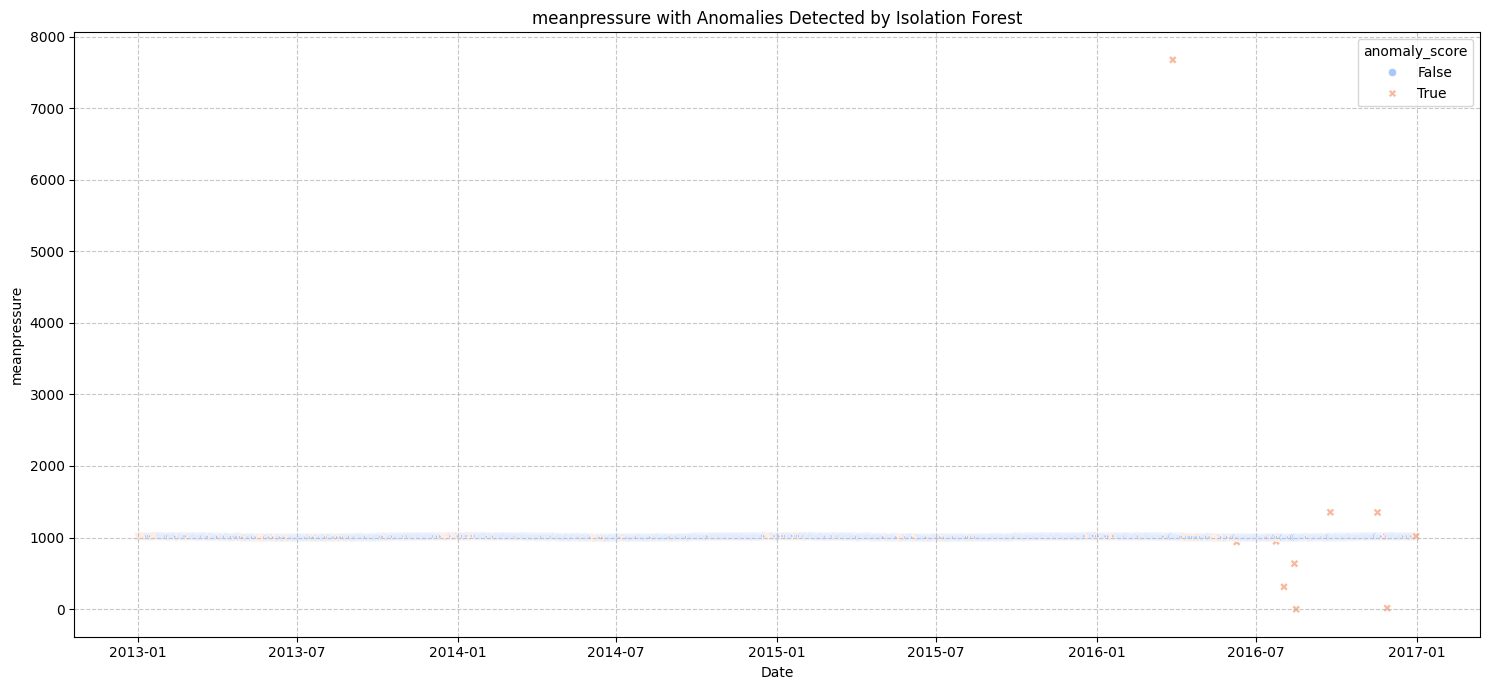

In [12]:
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

for col in features:
    plt.figure(figsize=(15, 7))
    sns.scatterplot(data=df.reset_index(), x='date', y=col, hue='anomaly_score', style='anomaly_score', palette='coolwarm')
    plt.title(f'{col} with Anomalies Detected by Isolation Forest')
    plt.xlabel('Date')
    plt.ylabel(f'{col}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

<Axes: >

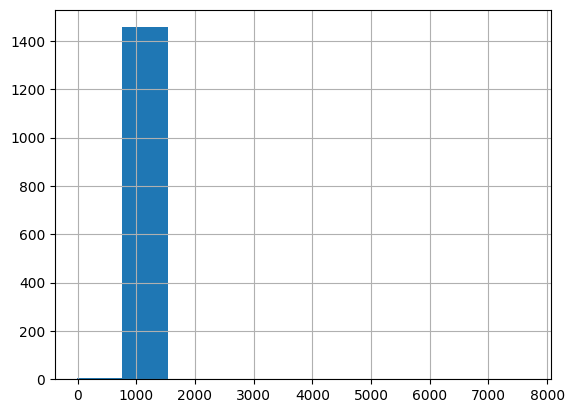

In [13]:
df['meanpressure'].hist()

<Axes: >

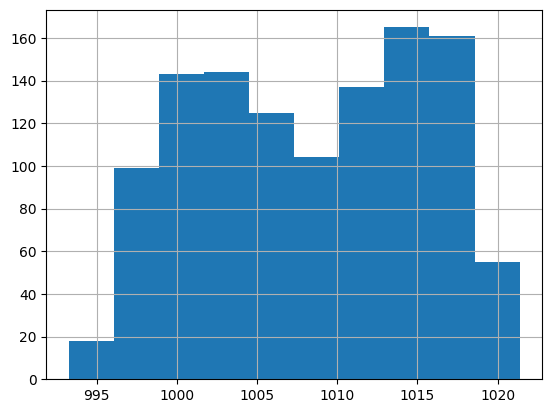

In [14]:
df[~df['anomaly_score']]['meanpressure'].hist()

### Isolation Forest on 'meanpressure' with 5% Contamination

Now, let's apply the Isolation Forest specifically to the 'meanpressure' column with a predefined contamination of 5%.

In [15]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model for 'meanpressure' with smaller percentage of contamination
model_meanpressure = IsolationForest(contamination=0.01, random_state=42)

# Fit the model and predict anomalies for 'meanpressure'
# Reshape the 'meanpressure' column to a 2D array as required by fit_predict
df['meanpressure_anomaly'] = model_meanpressure.fit_predict(df[['meanpressure']]) == -1

# Display the value counts for the new anomaly column
print('Value counts for meanpressure_anomaly:')
display(df['meanpressure_anomaly'].value_counts())

# Display the head of the DataFrame with the new anomaly column
display(df.head())

Value counts for meanpressure_anomaly:


meanpressure_anomaly
False    1446
True       15
Name: count, dtype: int64

,meantemp,humidity,wind_speed,meanpressure,year,anomaly_score,meanpressure_anomaly
date,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,True,False
2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,True,False
2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,True,False
2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,True,False
2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,True,False


Let's visualize the anomalies in 'meanpressure' based on this specific Isolation Forest run.

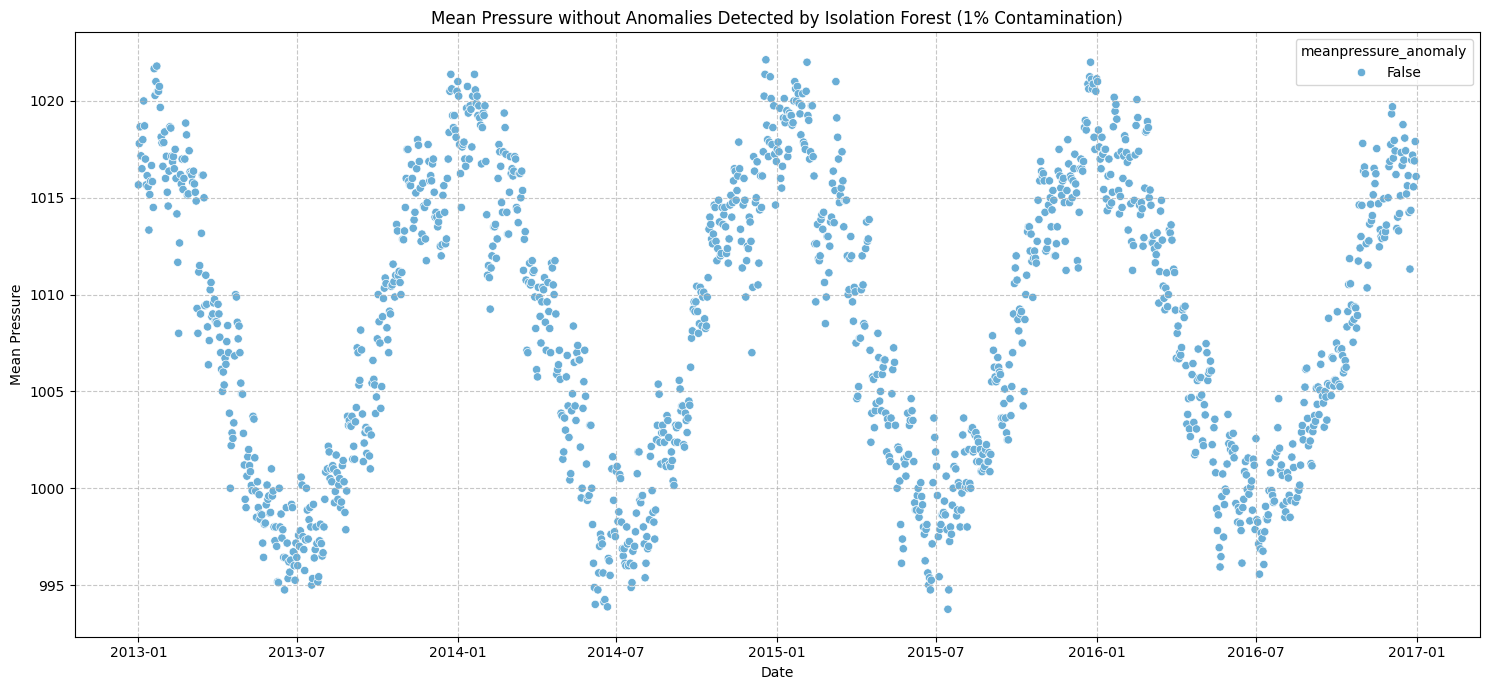

In [16]:
plt.figure(figsize=(15, 7))
sns.scatterplot(data=df[~df['meanpressure_anomaly']].reset_index(), x='date', y='meanpressure', hue='meanpressure_anomaly', style='meanpressure_anomaly', palette='Blues')
plt.title('Mean Pressure without Anomalies Detected by Isolation Forest (1% Contamination)')
plt.xlabel('Date')
plt.ylabel('Mean Pressure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Imputación de Anomalías en 'meanpressure' mediante Interpolación Temporal

Dado que el dataset es una serie temporal diaria con alta autocorrelación ($AR(1) \approx 0.975$), las lecturas fuera de los límites físicos plausibles en superficie para Delhi ($[950, 1050]\text{ hPa}$) corresponden a fallos de sensor aislados.

Se sustituyen estas anomalías por `NaN` y se sobreescriben mediante interpolación lineal temporal (`interpolate(method='time')`), preservando la inercia física del clima.

In [17]:
import numpy as np

display(df['meanpressure'].describe())

pressure_anomalies_mask = ~df['meanpressure'].between(950, 1050)
print(f"Anomalías detectadas en 'meanpressure': {pressure_anomalies_mask.sum()}")
display(df.loc[pressure_anomalies_mask, ['meanpressure']])

df.loc[pressure_anomalies_mask, 'meanpressure'] = np.nan
print(f'Nulls in meanpressure: {df["meanpressure"].isna().sum()}')

count    1461.000000
mean     1011.101197
std       180.293335
min        -3.041667
25%      1001.571429
50%      1008.555556
75%      1014.937500
max      7679.333333
Name: meanpressure, dtype: float64

Anomalías detectadas en 'meanpressure': 9


,meanpressure
date,
2016-03-28,7679.333333
2016-06-09,938.066667
2016-07-24,946.312500
2016-08-02,310.437500
2016-08-14,633.900000
2016-08-16,-3.041667
2016-09-24,1352.615385
2016-11-17,1350.296296
2016-11-28,12.045455


Nulls in meanpressure: 9


In [18]:
# 4. Imputar mediante interpolación temporal lineal
df['meanpressure'] = df['meanpressure'].interpolate(method='time')

# 5. Estadísticas descriptivas tras la imputación
print("\nEstadísticas de 'meanpressure' tras la imputación:")
display(df['meanpressure'].describe())


Estadísticas de 'meanpressure' tras la imputación:


count    1461.000000
mean     1008.244547
std         7.437207
min       991.375000
25%      1001.625000
50%      1008.555556
75%      1014.875000
max      1023.000000
Name: meanpressure, dtype: float64

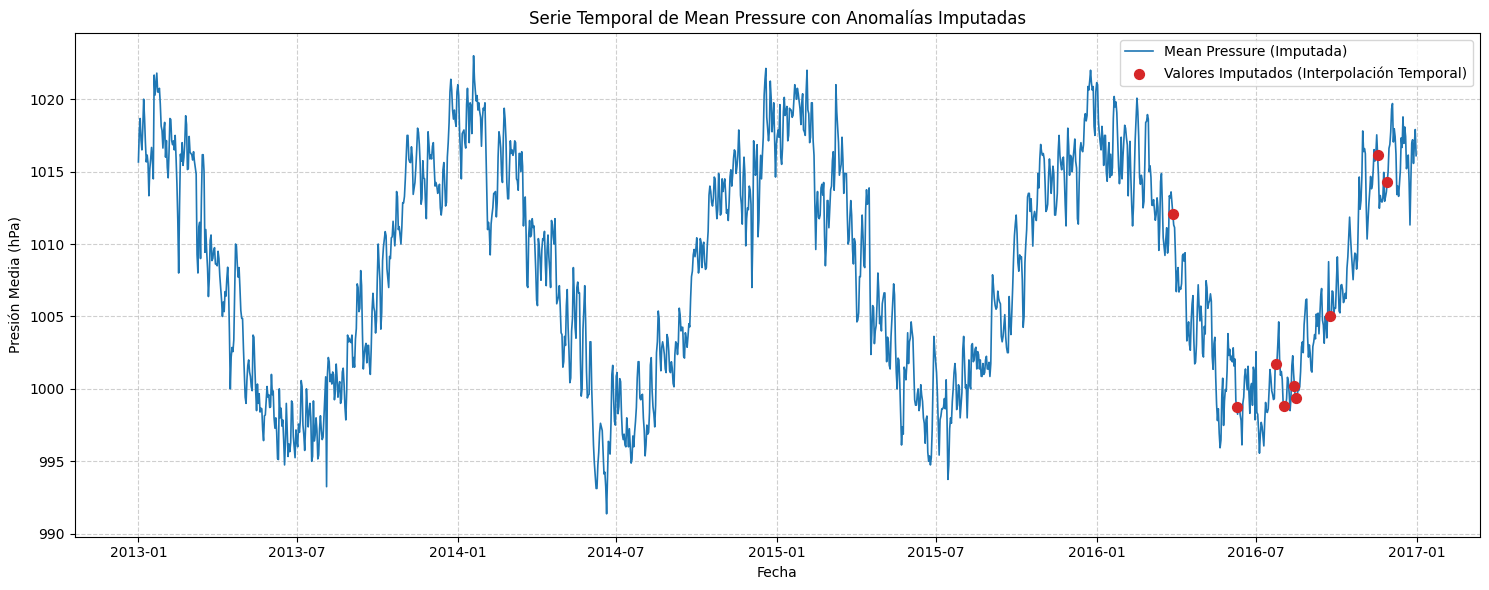

In [19]:
# Visualización de la serie temporal con los valores imputados
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['meanpressure'], color='#1f77b4', linewidth=1.2, label='Mean Pressure (Imputada)')
plt.scatter(df.index[pressure_anomalies_mask], df.loc[pressure_anomalies_mask, 'meanpressure'], 
            color='#d62728', s=50, zorder=5, label='Valores Imputados (Interpolación Temporal)')
plt.title('Serie Temporal de Mean Pressure con Anomalías Imputadas')
plt.xlabel('Fecha')
plt.ylabel('Presión Media (hPa)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

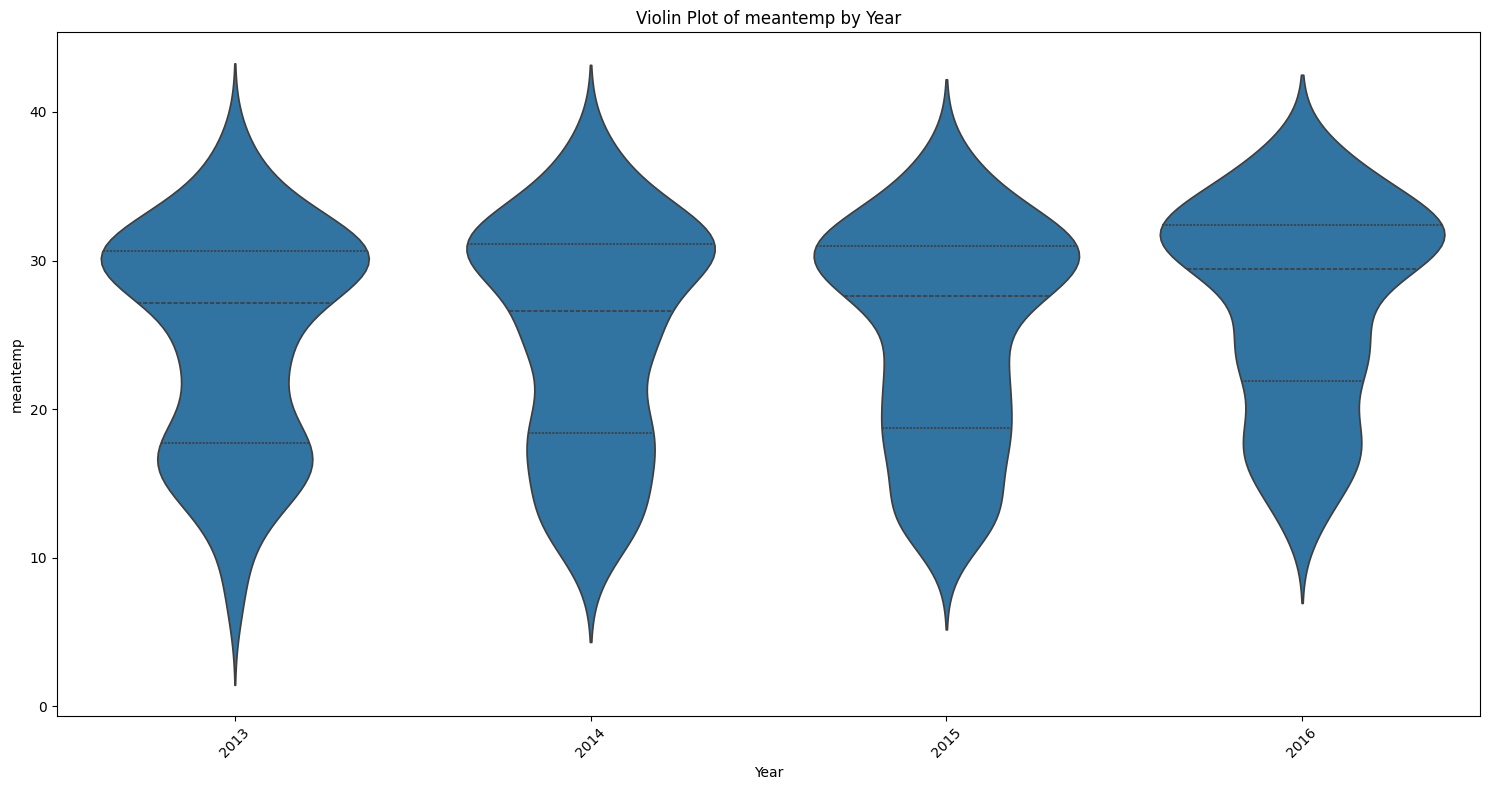

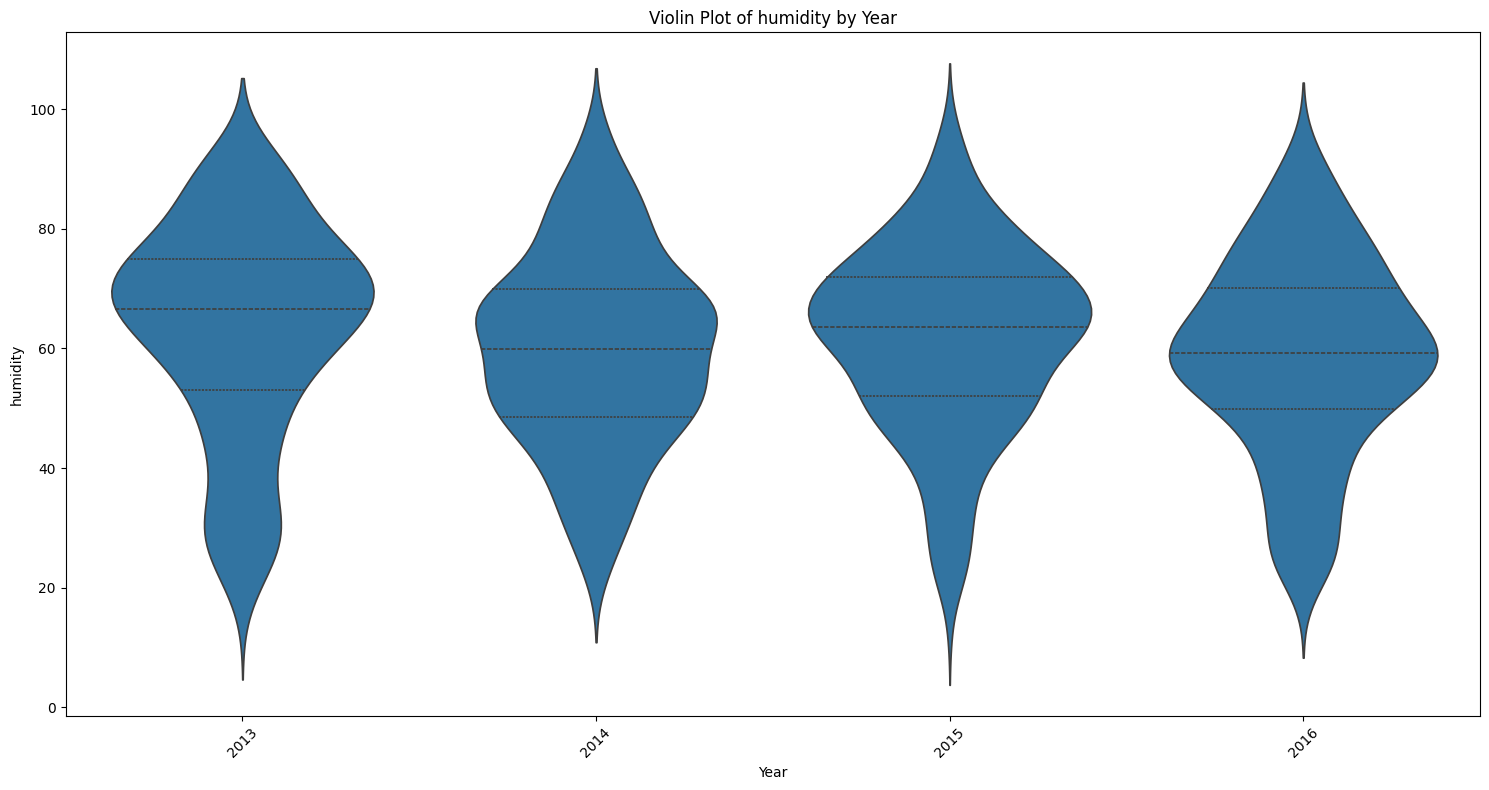

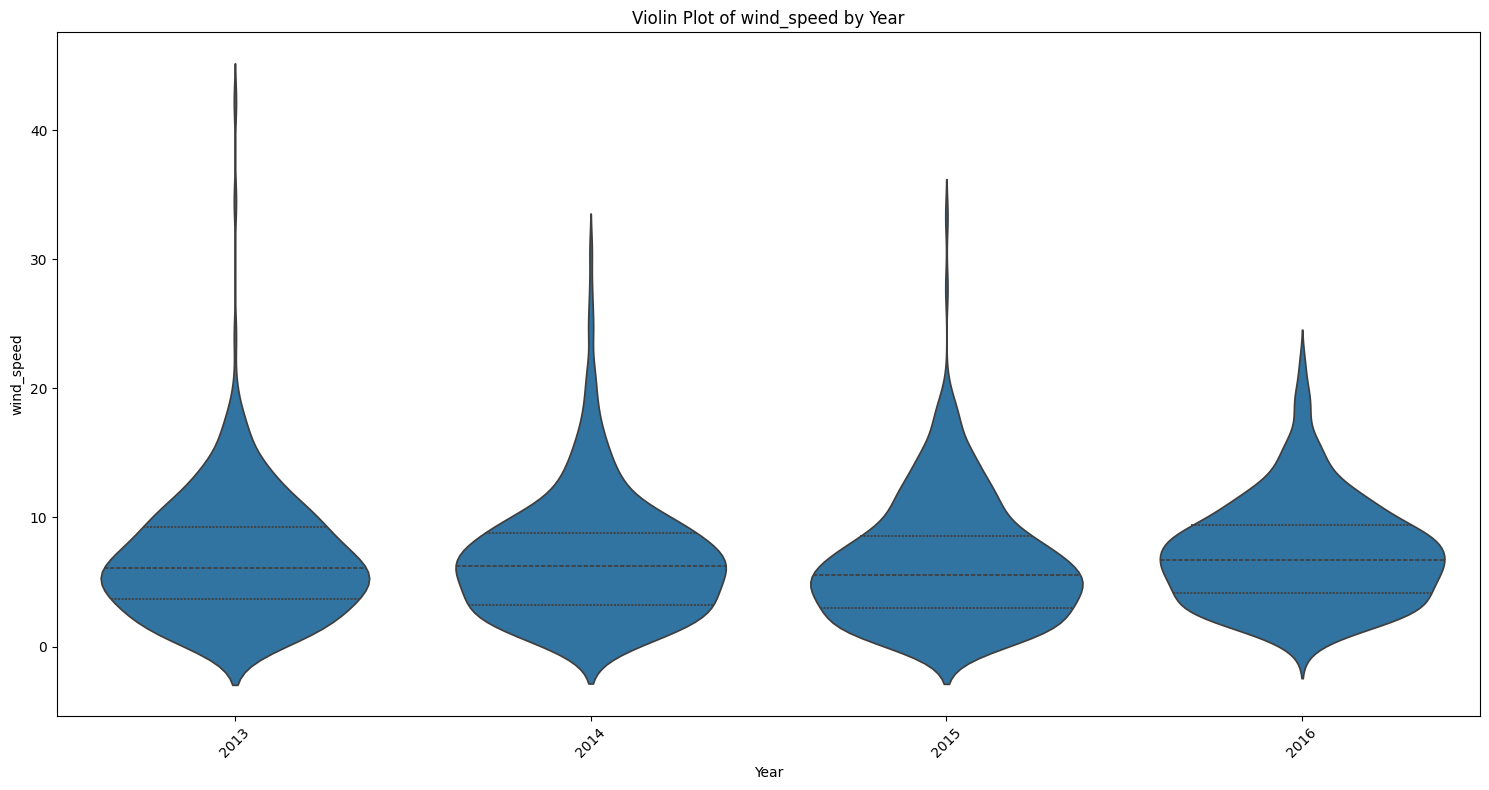

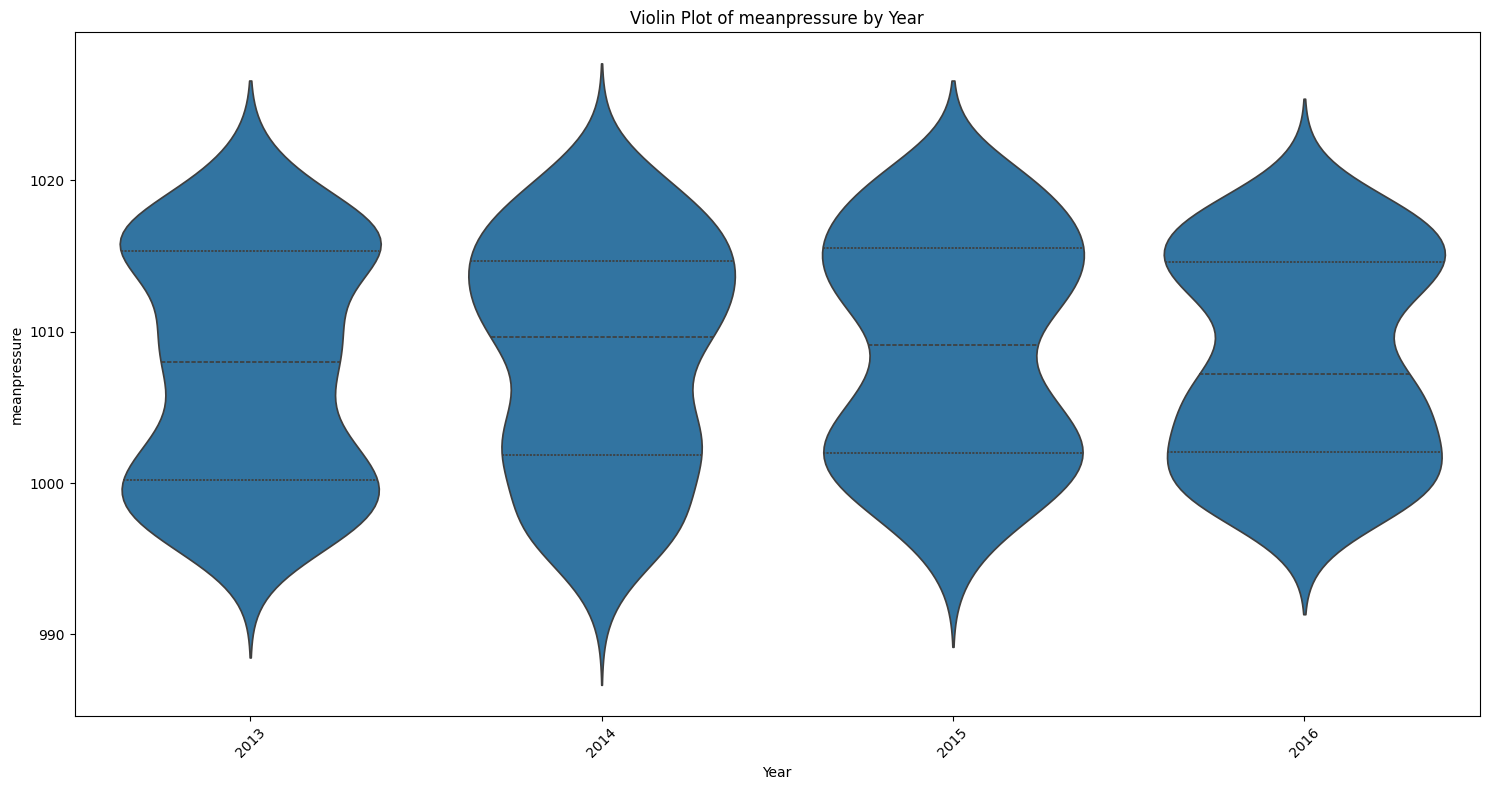

In [20]:
for col in features:
    plt.figure(figsize=(15, 8))
    sns.violinplot(data=df, x='year', y=col, inner='quartile')
    plt.title(f'Violin Plot of {col} by Year')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
df[['meantemp']].shift(range(5)).head(15).style.background_gradient(cmap='Blues', axis=None).format(precision=2, na_rep="-")


,meantemp_0,meantemp_1,meantemp_2,meantemp_3,meantemp_4
date,,,,,
2013-01-01 00:00:00,10.00,-,-,-,-
2013-01-02 00:00:00,7.40,10.00,-,-,-
2013-01-03 00:00:00,7.17,7.40,10.00,-,-
2013-01-04 00:00:00,8.67,7.17,7.40,10.00,-
2013-01-05 00:00:00,6.00,8.67,7.17,7.40,10.00
2013-01-06 00:00:00,7.00,6.00,8.67,7.17,7.40
2013-01-07 00:00:00,7.00,7.00,6.00,8.67,7.17
2013-01-08 00:00:00,8.86,7.00,7.00,6.00,8.67
2013-01-09 00:00:00,14.00,8.86,7.00,7.00,6.00


In [22]:
X = df[features].shift(range(30)).dropna()

X.head()

,meantemp_0,humidity_0,wind_speed_0,meanpressure_0,meantemp_1,humidity_1,wind_speed_1,meanpressure_1,meantemp_2,humidity_2,...,wind_speed_27,meanpressure_27,meantemp_28,humidity_28,wind_speed_28,meanpressure_28,meantemp_29,humidity_29,wind_speed_29,meanpressure_29
date,,,,,,,,,,,,,,,,,,,,,
2013-01-30,14.714286,70.428571,1.057143,1017.857143,14.125000,65.500000,3.237500,1016.625000,14.833333,56.000000,...,4.633333,1018.666667,7.400000,92.000000,2.980000,1017.800000,10.000000,84.500000,0.000000,1015.666667
2013-01-31,16.200000,65.600000,2.960000,1018.400000,14.714286,70.428571,1.057143,1017.857143,14.125000,65.500000,...,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667,7.400000,92.000000,2.980000,1017.800000
2013-02-01,16.000000,73.000000,2.220000,1016.000000,16.200000,65.600000,2.960000,1018.400000,14.714286,70.428571,...,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667
2013-02-02,16.285714,77.571429,1.328571,1017.142857,16.000000,73.000000,2.220000,1016.000000,16.200000,65.600000,...,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667
2013-02-03,18.000000,65.571429,1.857143,1015.285714,16.285714,77.571429,1.328571,1017.142857,16.000000,73.000000,...,6.300000,1020.000000,7.000000,82.800000,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000


In [23]:
# 1. Discretizar target en 5 clases según la consigna:
# 0: <14 | 1: 14-22 | 2: 22-27 | 3: 27-33 | 4: >33
bins = [-np.inf, 14, 22, 27, 33, np.inf]
class_names = ['<14', '14-22', '22-27', '27-33', '>33']
y = pd.cut(X['meantemp_0'], bins=bins, right=False, labels=[0, 1, 2, 3, 4]).to_numpy(dtype=np.int64)

# 2. Filtrar X eliminando el lag 0 (conservando los 29 lags pasados completos: 116 columnas)
X = X.drop(columns=X.filter(regex='_0$').columns).to_numpy(dtype=np.float32)

print(f"Dimensiones corregidas -> X: {X.shape} (116 features), y: {y.shape}")
print("\nDistribución de clases en y:")
print(pd.Series(y).value_counts().sort_index())

Dimensiones corregidas -> X: (1432, 116) (116 features), y: (1432,)

Distribución de clases en y:
0    101
1    343
2    218
3    570
4    200
Name: count, dtype: int64


### Partición Estratificada (`stratify=y`) y Ponderación de Clases (`class_weights`)

* **`stratify=y`:** El dataset presenta desbalance natural (la clase `27-33` tiene ~40% de muestras frente a ~8% de `<14`). La estratificación garantiza que los conjuntos de train y test repliquen de manera idéntica las proporciones poblacionales de cada régimen térmico.
* **`class_weights`:** Penalizar los errores de las clases minoritarias con pesos inversamente proporcionales a su frecuencia ($w_c = \frac{N}{C \cdot N_c}$) evita que el modelo ignore las olas de frío (`<14`) o calor extremo (`>33`), maximizando el recall macro.

In [25]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

# 1. Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42, stratify=y
)

# 2. Escalamiento estándar (fit en train, transform en test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Cálculo de class weights balanceados
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)
for c_name, w in zip(class_names, weights):
    print(f"Clase {c_name:>5s} -> Peso asignado: {w:.4f}")

# 4. DataLoaders para PyTorch Lightning
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)),
    batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)),
    batch_size=64, shuffle=False
)

Clase   <14 -> Peso asignado: 2.8272
Clase 14-22 -> Peso asignado: 0.8358
Clase 22-27 -> Peso asignado: 1.3161
Clase 27-33 -> Peso asignado: 0.5022
Clase   >33 -> Peso asignado: 1.4312


In [28]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
import torchmetrics
from torch import nn

# Fijar semilla de reproducibilidad
pl.seed_everything(42)

class WeatherLightningClassifier(pl.LightningModule):
    def __init__(self, in_features, num_classes=5, class_weights=None, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        
        # Función de pérdida ponderada por clases
        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.criterion = nn.CrossEntropyLoss()
            
        # Arquitectura MLP profunda con BatchNorm y Dropout
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
        
        # Métricas de TorchMetrics
        self.train_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes)
        self.val_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes)
        self.val_f1 = torchmetrics.classification.MulticlassF1Score(num_classes=num_classes, average='macro')
        
        self.test_preds = []
        self.test_targets = []

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.train_acc(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.val_acc(logits, y)
        f1 = self.val_f1(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        self.test_preds.append(preds.cpu())
        self.test_targets.append(y.cpu())

    def configure_optimizers(self):
        # Adam dinámico: AdamW con programador de tasa de aprendizaje adaptativo (ReduceLROnPlateau)
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }

Seed set to 42


In [29]:
# 1. Instanciar modelo con class weights
model = WeatherLightningClassifier(
    in_features=X.shape[1], 
    num_classes=5, 
    class_weights=class_weights_tensor, 
    lr=1e-3
)

# 2. EarlyStopping: se detiene si 'val_loss' no mejora en 8 épocas
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=8,
    mode='min',
    verbose=True
)

# 3. Checkpoint del mejor modelo por val_loss
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    filename='best_weather_model-{epoch:02d}-{val_loss:.3f}'
)

# 4. PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=60,
    callbacks=[early_stop_callback, checkpoint_callback],
    accelerator='auto',
    enable_progress_bar=True
)

# 5. Entrenar y validar
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 1 │ net       │ Sequential         │ 25.9 K │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 25.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 25.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\efrai\OneDrive\Desktop\EF\Academic\Professor\DL 
classes\uag-deep-learning\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

...

Metric val_loss improved by 0.018 >= min_delta = 0.0. New best score: 0.464


Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.458


Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.455


Metric val_loss improved by 0.013 >= min_delta = 0.0. New best score: 0.442


Monitored metric val_loss did not improve in the last 8 records. Best score: 0.442. Signaling Trainer to stop.


Restoring states from the checkpoint path at c:\Users\efrai\OneDrive\Desktop\EF\Academic\Professor\DL classes\uag-deep-learning\parcial_1\lightning_logs\version_0\checkpoints\best_weather_model-epoch=16-val_loss=0.442.ckpt
c:\Users\efrai\OneDrive\Desktop\EF\Academic\Professor\DL classes\uag-deep-learning\.venv\lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializat

Output()

c:\Users\efrai\OneDrive\Desktop\EF\Academic\Professor\DL classes\uag-deep-learning\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.



CLASSIFICATION REPORT
              precision    recall  f1-score   support

         <14     0.6552    0.9500    0.7755        40
       14-22     0.9423    0.7101    0.8099       138
       22-27     0.7037    0.8636    0.7755        88
       27-33     0.9263    0.7719    0.8421       228
         >33     0.6491    0.9250    0.7629        80

    accuracy                         0.8049       574
   macro avg     0.7753    0.8441    0.7932       574
weighted avg     0.8385    0.8049    0.8085       574



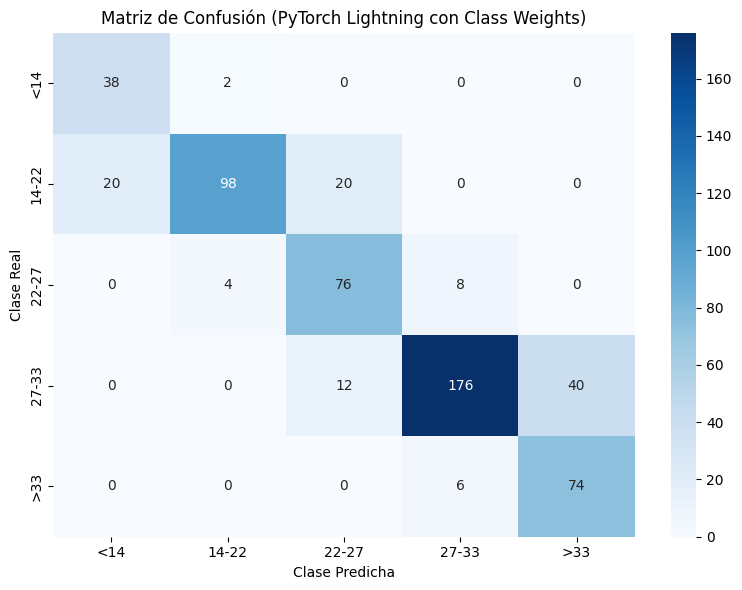

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluación sobre el conjunto de test con los pesos del mejor checkpoint restaurado
trainer.test(model, val_loader, ckpt_path='best')

all_preds = torch.cat(model.test_preds).numpy()
all_targets = torch.cat(model.test_targets).numpy()

# 1. Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión (PyTorch Lightning con Class Weights)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()

### Evaluación en el Conjunto de Test Independiente (`DailyDelhiClimateTest.csv`)

Para evaluar correctamente una serie temporal con ventana de retardo ($29$ lags) sin descartar datos:
1. **Lookback / Warm-up:** Se concatenan los últimos 29 días del set de entrenamiento (`df.tail(29)`) con `df_test` para que el primer día de prueba (`2017-01-01`) disponga de su ventana histórica completa, preservando los **114 días completos**.
2. **Limpieza física de sensor:** `DailyDelhiClimateTest.csv` contiene en su fila inicial una lectura corrupta de presión (`meanpressure = 59.0`). Se filtra con el rango físico $[950, 1050]\text{ hPa}$ e interpolación temporal.
3. **Transformación:** Se escala con el `scaler` ajustado en entrenamiento y se infiere con el mejor modelo.

REPORTE DE EVALUACIÓN OFICIAL (TEST: 114 DÍAS)
              precision    recall  f1-score   support

         <14     0.4615    0.8571    0.6000         7
       14-22     0.8000    0.7097    0.7521        62
       22-27     0.2222    0.3077    0.2581        13
       27-33     0.9412    0.5714    0.7111        28
         >33     0.3636    1.0000    0.5333         4

    accuracy                         0.6491       114
   macro avg     0.5577    0.6892    0.5709       114
weighted avg     0.7327    0.6491    0.6687       114



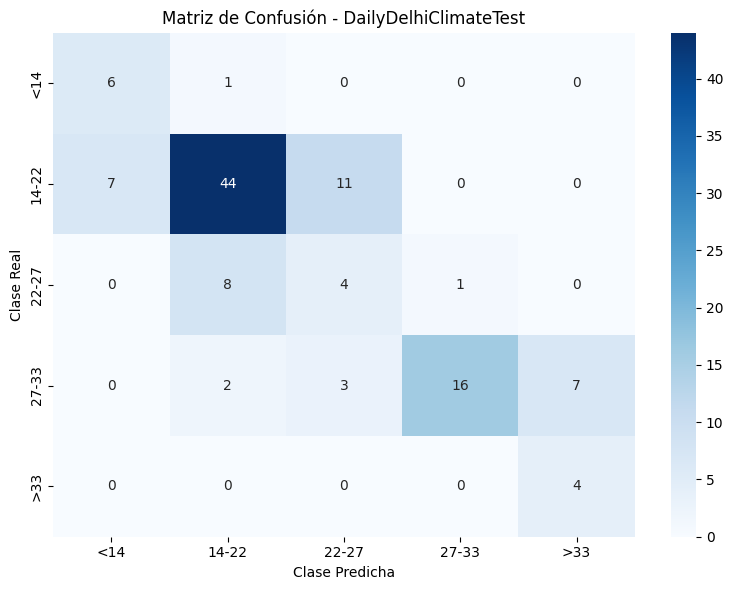

In [32]:
# 1. Cargar archivo de prueba oficial
test_file = file_dict['DailyDelhiClimateTest']
df_test = pd.read_csv(test_file)
df_test['date'] = pd.to_datetime(df_test['date'])
df_test.set_index('date', inplace=True)
df_test.sort_index(inplace=True)

# 2. Concatenar los últimos 29 días de train como buffer histórico para no perder los primeros 29 días de test
df_test_combined = pd.concat([df[features].tail(29), df_test[features]])

# 3. Limpiar anomalía de meanpressure en test (ej. 2017-01-01 = 59.0 hPa)
df_test_combined['meanpressure'] = df_test_combined['meanpressure'].mask(
    ~df_test_combined['meanpressure'].between(950, 1050)
).interpolate(method='time')

# 4. Generar matriz de lags (shift 0 a 29)
X_test_full = df_test_combined.shift(range(30)).dropna()
y_test_final = pd.cut(X_test_full['meantemp_0'], bins=bins, right=False, labels=[0, 1, 2, 3, 4]).to_numpy(dtype=np.int64)
X_test_final = X_test_full.drop(columns=X_test_full.filter(regex='_0$').columns).to_numpy(dtype=np.float32)

# 5. Escalar con el scaler pre-ajustado
X_test_scaled = scaler.transform(X_test_final)

# 6. Inferencia con el modelo entrenado
model.eval()
device = next(model.parameters()).device
with torch.no_grad():
    x_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
    logits = model(x_tensor)
    test_preds = torch.argmax(logits, dim=1).cpu().numpy()

# 7. Reporte de Clasificación y Matriz de Confusión Oficial
print("="*60)
print(f"REPORTE DE EVALUACIÓN OFICIAL (TEST: {len(y_test_final)} DÍAS)")
print("="*60)
print(classification_report(y_test_final, test_preds, target_names=class_names, digits=4, zero_division=0))

cm_test = confusion_matrix(y_test_final, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - DailyDelhiClimateTest')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()